In [1]:
import torch
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

clear_gpu()

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import ChebConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pickle
import random, warnings, os
import datetime
import time 

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rulăm pe: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


CSV_PATH = "PEMS-BAY.csv"
ADJ_PATH = "Rezultate/adj_mx_bay.pkl"

if not os.path.exists("Rezultate"):
    os.makedirs("Rezultate")

# ÎNCĂRCARE GRAF 
with open(ADJ_PATH, 'rb') as f:
    _, _, adj_mx = pickle.load(f)
adj_sparse = adj_mx > 0
edge_index = torch.tensor(np.array(np.where(adj_sparse)), dtype=torch.long).to(device)
edge_weight = torch.tensor(adj_mx[adj_sparse], dtype=torch.float).to(device)

# Construirea secvențelor de intrare folosind o fereastră temporală
def build_dataset(data, lookback=12):
    X, y = [], []
    for i in range(len(data)-lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

print("Încarc date...")
df = pd.read_csv(CSV_PATH).dropna()
data = df.iloc[:,1:].values.astype(np.float32)

LOOKBACK = 12
X, y = build_dataset(data, LOOKBACK)

# Împărțirea datelor în seturi de antrenare, validare și testare
n_samples = len(X)
train_end = int(0.7*n_samples)
val_end   = int(0.85*n_samples)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

# Normalizarea datelor
scaler_X = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_val_s = scaler_X.transform(X_val.reshape(-1, X_val.shape[2])).reshape(X_val.shape)
X_test_s = scaler_X.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Conversia datelor în tensori PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32).unsqueeze(-1)
y_val_t   = torch.tensor(y_val_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32).unsqueeze(-1)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32)


Rulăm pe: cuda
GPU: NVIDIA GeForce RTX 3080 Laptop GPU
Încarc date...


In [3]:
class STGCN(nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_channels=64, K=3, dropout_prob=0.2):
        super(STGCN, self).__init__()
        # Prima convoluție temporală
        self.t_conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=(3, 1))
        # Convoluție pe graf
        self.gcn = ChebConv(hidden_channels, hidden_channels, K=K)
        # A doua convoluție temporală
        self.t_conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=(3, 1))
        self.dropout = nn.Dropout(dropout_prob)
        # Strat complet conectat pentru predicția finală
        self.fc = nn.Linear(hidden_channels * 8, 1)

    def forward(self, x, edge_index, edge_weight):
        # Reordonarea dimensiunilor pentru Conv2D
        x = x.permute(0, 3, 1, 2)
        # Extragerea caracteristicilor temporale
        x = torch.relu(self.t_conv1(x))
        b, c, t, n = x.shape
        # Agregarea informației spațiale folosind graful
        x = x.permute(0, 2, 3, 1).reshape(-1, c)
        x = torch.relu(self.gcn(x, edge_index, edge_weight))
        x = x.reshape(b, t, n, c)
        # Extragerea caracteristicilor temporale finale
        x = x.permute(0, 3, 1, 2)
        x = torch.relu(self.t_conv2(x))
        # Pregătirea pentru stratul de ieșire
        x = x.permute(0, 3, 1, 2)
        x = torch.flatten(x, start_dim=2)
        out = self.fc(self.dropout(x))
        return out.squeeze(-1)

In [4]:
h_units = 32
lr = 0.001
batch_size = 16
epochs = 50

model = STGCN_Simple(num_nodes=325, hidden_channels=h_units).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

print(f"\n Începe antrenamentul STGCN ... ")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb, edge_index, edge_weight)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            v_pred = model(X_val_t.to(device), edge_index, edge_weight)
            v_loss = criterion(v_pred, y_val_t.to(device))
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(train_loader):.6f} | Val MSE: {v_loss.item():.6f}")

total_time = (time.time() - start_time) / 60
print(f"\n Finalizat în {total_time:.2f} minute.")


 Începe antrenamentul STGCN ... 
Epoch 5/50 | Loss: 0.000868 | Val MSE: 0.000827
Epoch 10/50 | Loss: 0.000791 | Val MSE: 0.000932
Epoch 15/50 | Loss: 0.000773 | Val MSE: 0.000981
Epoch 20/50 | Loss: 0.000757 | Val MSE: 0.001068
Epoch 25/50 | Loss: 0.000739 | Val MSE: 0.000959
Epoch 30/50 | Loss: 0.000719 | Val MSE: 0.001007
Epoch 35/50 | Loss: 0.000707 | Val MSE: 0.001079
Epoch 40/50 | Loss: 0.000704 | Val MSE: 0.000991
Epoch 45/50 | Loss: 0.000703 | Val MSE: 0.000949
Epoch 50/50 | Loss: 0.000703 | Val MSE: 0.000960

 Finalizat în 23.31 minute.


In [5]:
#Calculul metricilor de evaluare

model.eval()
with torch.no_grad():
    pred_test = model(X_test_t.to(device), edge_index, edge_weight).cpu().numpy()

y_pred_inv = scaler_y.inverse_transform(pred_test)
y_real_inv = scaler_y.inverse_transform(y_test_s)

mse  = mean_squared_error(y_real_inv, y_pred_inv)
mae = mean_absolute_error(y_real_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_real_inv, y_pred_inv))
r2 = r2_score(y_real_inv, y_pred_inv)
var_ratio = np.var(y_pred_inv) / np.var(y_real_inv)

print("  REZULTATE FINALE STGCN")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f} mph")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"Var  : {var_ratio:.4f}")

results = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "model": "STGCN",
    "version": "v1",
    "lookback": LOOKBACK,
    "hidden_units": h_units,
    "learning_rate": f"{lr:.6f}",
    "dropout": "0.20",
    "batch_size": batch_size,
    "epochs": epochs,
    "MSE": f"{mean_squared_error(y_real_inv, y_pred_inv):.6f}",
    "MAE": f"{mae:.4f}",
    "RMSE": f"{rmse:.4f}",
    "R2": f"{r2:.4f}",
    "Var_Ratio": f"{var_ratio:.4f}"
}

results_path = "Rezultate/log_experimente.csv"
pd.DataFrame([results]).to_csv(results_path, mode='a', header=not os.path.exists(results_path), index=False)
np.save("Rezultate/preds_STGCN_Fast.npy", y_pred_inv)

  REZULTATE FINALE STGCN
MSE  : 3.6662
MAE  : 1.0263 mph
RMSE : 1.9147
R2   : 0.9271
Var  : 0.9775


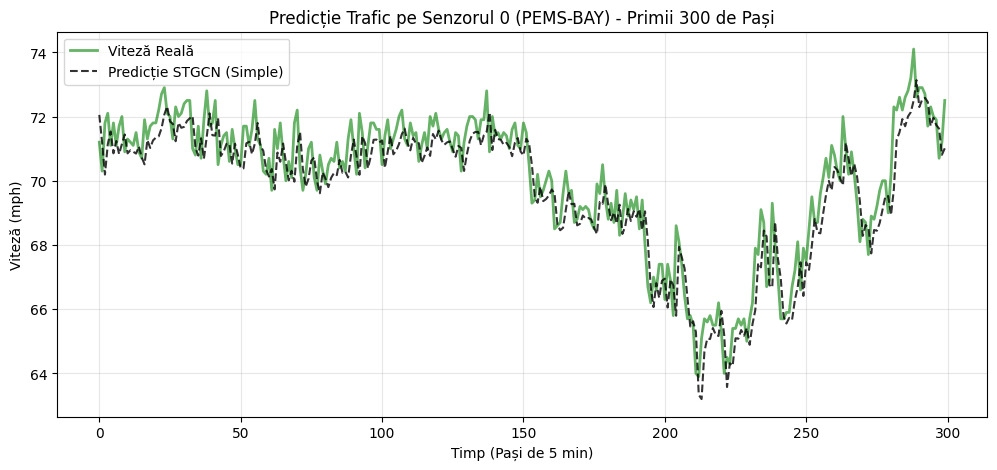


 Generez vizualizarea arhitecturii...


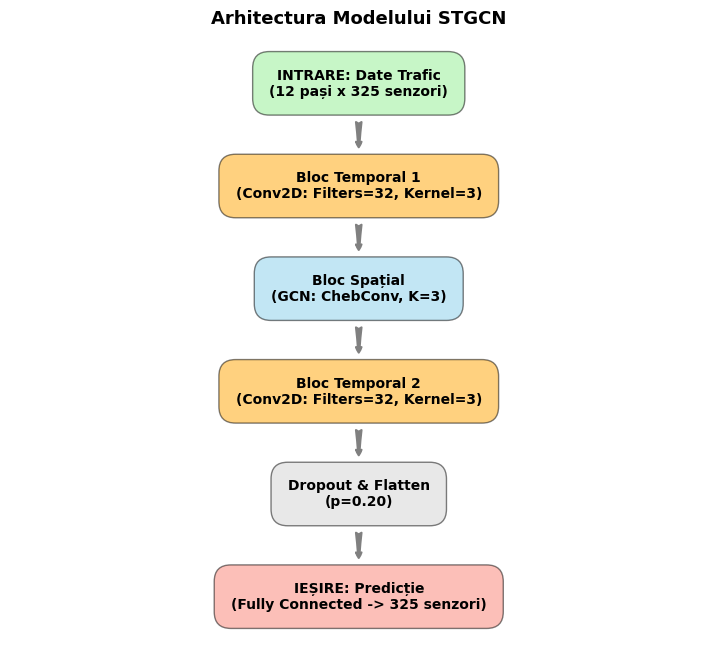

 Diagramele au fost salvate în folderul 'Rezultate'.


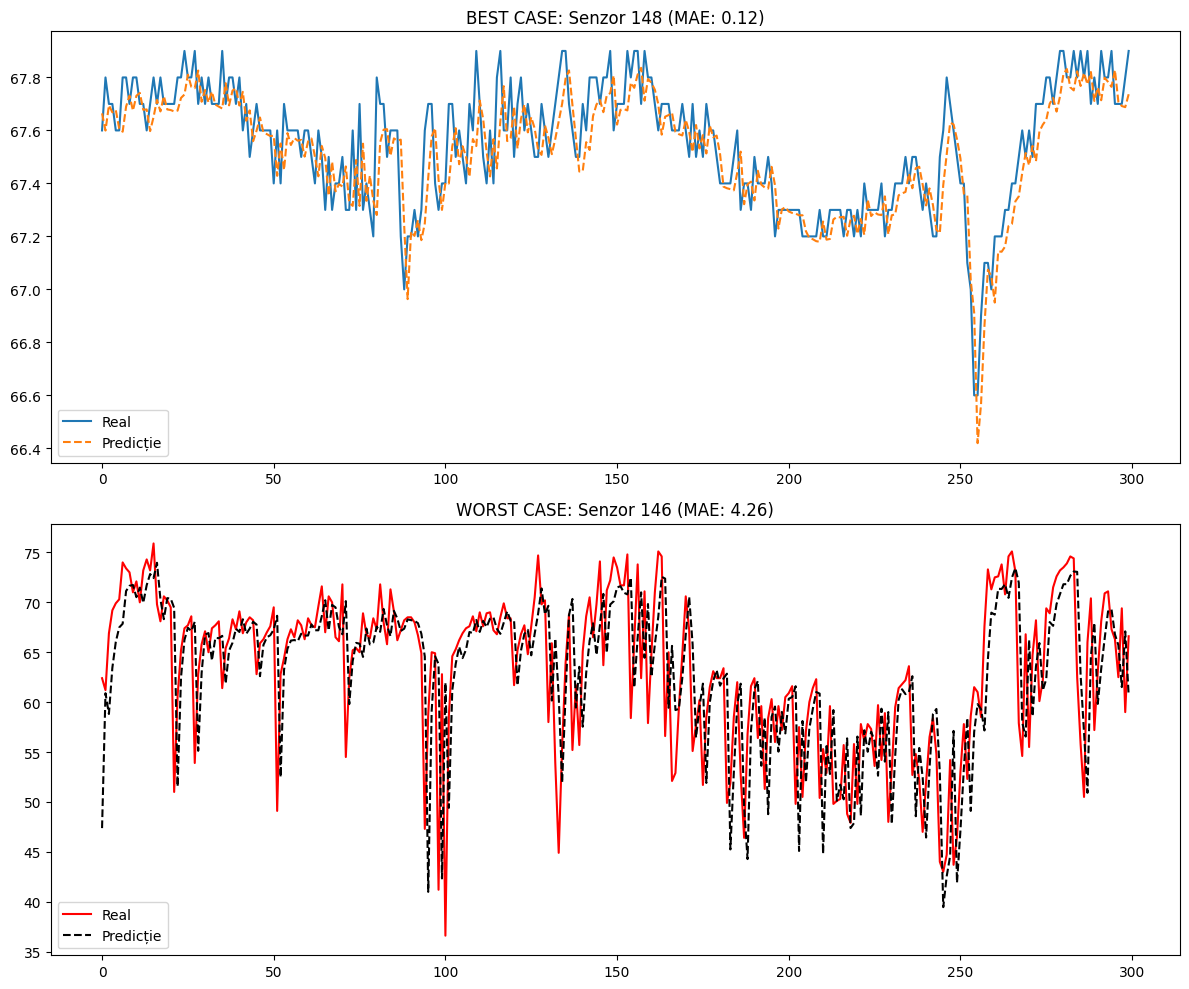

In [6]:
# Comparația dintre valorile reale și predicții

plt.figure(figsize=(12, 5))
plt.plot(y_real_inv[:300, 0], label="Viteză Reală", color='green', alpha=0.6, linewidth=2)
plt.plot(y_pred_inv[:300, 0], '--', label="Predicție STGCN (Simple)", color='black', alpha=0.8)

plt.title("Predicție Trafic pe Senzorul 0 (PEMS-BAY) - Primii 300 de Pași")
plt.ylabel("Viteză (mph)")
plt.xlabel("Timp (Pași de 5 min)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Rezultate/Predictie_Senzor_0.png", dpi=300, bbox_inches='tight')
plt.show()

# Diagrama Arhitecturii Modelului
def plot_architecture(num_nodes, hidden_channels, lookback):
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # Definirea straturilor
    layers = [
        f"INTRARE: Date Trafic\n({lookback} pași x {num_nodes} senzori)",
        f"Bloc Temporal 1\n(Conv2D: Filters={hidden_channels}, Kernel=3)",
        f"Bloc Spațial\n(GCN: ChebConv, K=3)",
        f"Bloc Temporal 2\n(Conv2D: Filters={hidden_channels}, Kernel=3)",
        f"Dropout & Flatten\n(p=0.20)",
        f"IEȘIRE: Predicție\n(Fully Connected -> {num_nodes} senzori)"
    ]
    
    y_pos = range(len(layers), 0, -1)
    for i, txt in enumerate(layers):
        if "INTRARE" in txt: box_color = 'lightgreen'
        elif "Temporal" in txt: box_color = 'orange'
        elif "Spațial" in txt: box_color = 'skyblue'
        elif "IEȘIRE" in txt: box_color = 'salmon'
        else: box_color = 'lightgray'
        
        ax.text(0.5, y_pos[i], txt, ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=1.2', facecolor=box_color, alpha=0.5))
        
        if i < len(layers) - 1:
            ax.annotate('', xy=(0.5, y_pos[i+1]+0.35), xytext=(0.5, y_pos[i]-0.35),
                        arrowprops=dict(arrowstyle='fancy', lw=1.5, color='gray'))

    plt.title("Arhitectura Modelului STGCN", fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, len(layers) + 0.5)
    ax.axis('off')
    
    # Salvare vizualizare
    plt.savefig("Rezultate/Arhitectura_STGCN.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_architecture(325, h_units, LOOKBACK)
print(f" Diagramele au fost salvate în folderul 'Rezultate'.")


# Identificarea senzorilor cu cea mai bună și cea mai slabă performanță
mae_per_sensor = np.mean(np.abs(y_real_inv - y_pred_inv), axis=0)
best_s, worst_s = np.argmin(mae_per_sensor), np.argmax(mae_per_sensor)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
ax1.plot(y_real_inv[:300, best_s], label="Real")
ax1.plot(y_pred_inv[:300, best_s], '--', label="Predicție")
ax1.set_title(f"BEST CASE: Senzor {best_s} (MAE: {mae_per_sensor[best_s]:.2f})")
ax1.legend()

ax2.plot(y_real_inv[:300, worst_s], color='red', label="Real")
ax2.plot(y_pred_inv[:300, worst_s], '--', color='black', label="Predicție")
ax2.set_title(f"WORST CASE: Senzor {worst_s} (MAE: {mae_per_sensor[worst_s]:.2f})")
ax2.legend()
plt.tight_layout()
plt.show()